# Diagnostic de Moteurs DC 12V par IA
### Projet de Fin d'Annee II — Classification des Types de Pannes

---

| Capteur | Colonne CSV | Role |
|---------|-------------|------|
| Courant | `Current`, `Normalized_Current` | Surcharge / Court-circuit |
| Tension | `Voltage`, `Normalized_Voltage` | Alimentation |
| Vibration / Temperature | `Vibration`, `Temperature`, ... | Anomalie mecanique |

**Classes cibles :**

| Label | Condition |
|-------|-----------|
| `Normal` | `Fault_Status == 0` (NaN dans Fault_Type) |
| `Electrical Fault` | `Fault_Status == 1` |
| `Overheating` | `Fault_Status == 1` |
| `Mechanical Failure` | `Fault_Status == 1` |

**Modeles :** Random Forest · MLP (sklearn)

---

## 1. Installation des Dependances

> Executez une seule fois pour installer les librairies manquantes.

In [34]:
import subprocess, sys

packages = ["numpy","pandas","scipy","scikit-learn","matplotlib","seaborn","joblib","imbalanced-learn"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("Toutes les librairies sont installees.")

Toutes les librairies sont installees.


---
## 2. Importation des Librairies

In [35]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 10

print("Librairies importees.")

Librairies importees.


---
## 3. Configuration

> **Modifiez uniquement cette cellule** si vous changez de dataset ou de chemin.

In [37]:
# =============================================================================
#  CONFIGURATION
# =============================================================================

# Chemin vers le CSV (relatif au dossier du notebook ou absolu)
DATA_PATH  = "dataset1\\iot_equipment_monitoring_dataset_cleaned.csv"

# Dossier de sortie (modeles + figures)
OUTPUT_DIR = "outputs"

# =============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : '{DATA_PATH}'\n"
        "Placez le CSV dans le meme dossier que ce notebook."
    )

print(f"Dataset   : {DATA_PATH}")
print(f"Sorties   : {OUTPUT_DIR}/")

Dataset   : dataset1\iot_equipment_monitoring_dataset_cleaned.csv
Sorties   : outputs/


---
## 4. Chargement du Dataset

In [38]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape brut : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
print(f"Colonnes   : {df_raw.columns.tolist()}")
print()
df_raw.head(8)

Shape brut : 50000 lignes x 17 colonnes
Colonnes   : ['Timestamp', 'Sensor_ID', 'Temperature', 'Vibration', 'Pressure', 'Voltage', 'Current', 'FFT_Feature1', 'FFT_Feature2', 'Normalized_Temp', 'Normalized_Vibration', 'Normalized_Pressure', 'Normalized_Voltage', 'Normalized_Current', 'Anomaly_Score', 'Fault_Type', 'Fault_Status']



,Timestamp,Sensor_ID,Temperature,Vibration,Pressure,Voltage,Current,FFT_Feature1,FFT_Feature2,Normalized_Temp,Normalized_Vibration,Normalized_Pressure,Normalized_Voltage,Normalized_Current,Anomaly_Score,Fault_Type,Fault_Status
0,2015-01-01 00:00:00,S151,47.698252,34.225292,176.199516,241.587771,8.323269,0.224737,0.093476,0.524226,0.211423,0.397119,0.800961,0.446526,0.239856,UNKNOWN,0
1,2015-01-01 00:01:00,S192,67.260549,134.072771,110.942636,235.003165,11.072823,0.973402,0.628513,0.682771,0.672347,0.240942,0.720230,0.552688,0.776081,UNKNOWN,0
2,2015-01-01 00:02:00,S114,45.056722,70.595452,246.739554,232.244324,10.353556,0.566625,0.417355,0.502817,0.379318,0.565941,0.686405,0.524917,0.039005,UNKNOWN,0
3,2015-01-01 00:03:00,S171,40.260670,98.252385,202.632051,225.922517,10.228006,0.872516,0.926135,0.463947,0.506990,0.460380,0.608896,0.520069,0.584953,UNKNOWN,0
4,2015-01-01 00:04:00,S160,56.311983,138.959633,231.149735,198.928891,18.878552,0.876380,0.174530,0.594037,0.694906,0.528630,0.277939,0.854070,0.944961,UNKNOWN,0
5,2015-01-01 00:05:00,S120,48.851961,89.867758,142.120604,228.280849,11.161220,0.223781,0.931844,0.533576,0.468284,0.315559,0.637810,0.556101,0.315629,Electrical Fault,1
6,2015-01-01 00:06:00,S182,31.917071,106.507310,242.739842,219.757681,6.852375,0.511208,0.505407,0.396325,0.545097,0.556369,0.533311,0.389735,0.201581,UNKNOWN,0
7,2015-01-01 00:07:00,S186,77.260525,120.374247,227.768841,226.807218,13.481133,0.664680,0.090581,0.763817,0.609110,0.520539,0.619743,0.645674,0.093058,UNKNOWN,0


---
## 5. Construction du Label Final

> **Probleme dans le CSV :** quand `Fault_Status == 0`, la colonne `Fault_Type` contient `NaN`.
> On remplace ces `NaN` par `"Normal"` pour avoir 4 classes propres.

```
Fault_Status == 0  -->  Label = "Normal"
Fault_Status == 1  -->  Label = Fault_Type  (Electrical Fault / Overheating / Mechanical Failure)
```

In [39]:
df = df_raw.copy()

# Construction du label : NaN -> "Normal"
df["Label"] = df.apply(
    lambda row: "Normal" if row["Fault_Status"] == 0 else str(row["Fault_Type"]),
    axis=1
)

# Verification : plus aucun NaN
assert df["Label"].isnull().sum() == 0, "Des NaN subsistent dans Label !"

print("Distribution des classes :")
print(df["Label"].value_counts().to_string())
print()
print(f"Aucun NaN dans Label : OK")

Distribution des classes :
Label
Normal                34988
Electrical Fault       5034
Overheating            5028
Mechanical Failure     4950

Aucun NaN dans Label : OK


---
## 6. Exploration des Donnees (EDA)

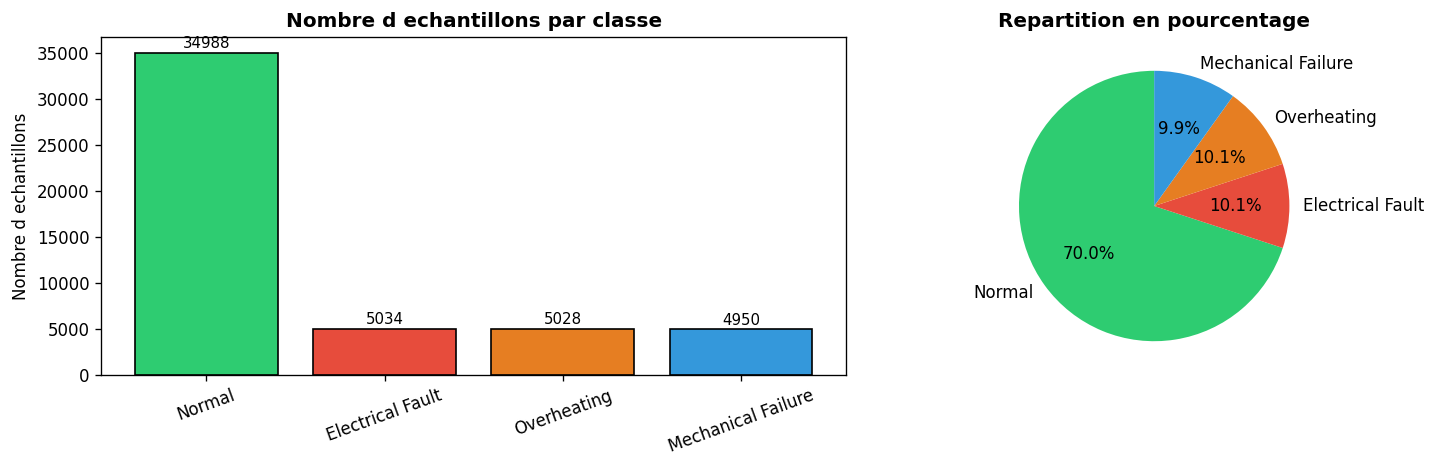

Figure sauvegardee : outputs/distribution_classes.png


In [40]:
label_counts = df["Label"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ["#2ecc71", "#e74c3c", "#e67e22", "#3498db"]

# Bar chart
bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=colors[:len(label_counts)], edgecolor="black")
axes[0].set_title("Nombre d echantillons par classe", fontweight="bold")
axes[0].set_ylabel("Nombre d echantillons")
axes[0].tick_params(axis="x", rotation=20)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 str(val), ha="center", va="bottom", fontsize=9)

# Pie chart
axes[1].pie(label_counts, labels=label_counts.index, autopct="%1.1f%%",
            colors=colors[:len(label_counts)], startangle=90)
axes[1].set_title("Repartition en pourcentage", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "distribution_classes.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/distribution_classes.png")

C:\Users\iyedd\AppData\Local\Temp\ipykernel_25384\3527110268.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, patch_artist=True, labels=label_counts.index)
C:\Users\iyedd\AppData\Local\Temp\ipykernel_25384\3527110268.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, patch_artist=True, labels=label_counts.index)
C:\Users\iyedd\AppData\Local\Temp\ipykernel_25384\3527110268.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, patch_artist=True, labels=label_counts.index)
C:\Users\iyedd\AppData\Local\Temp\ipykernel_25384\35271

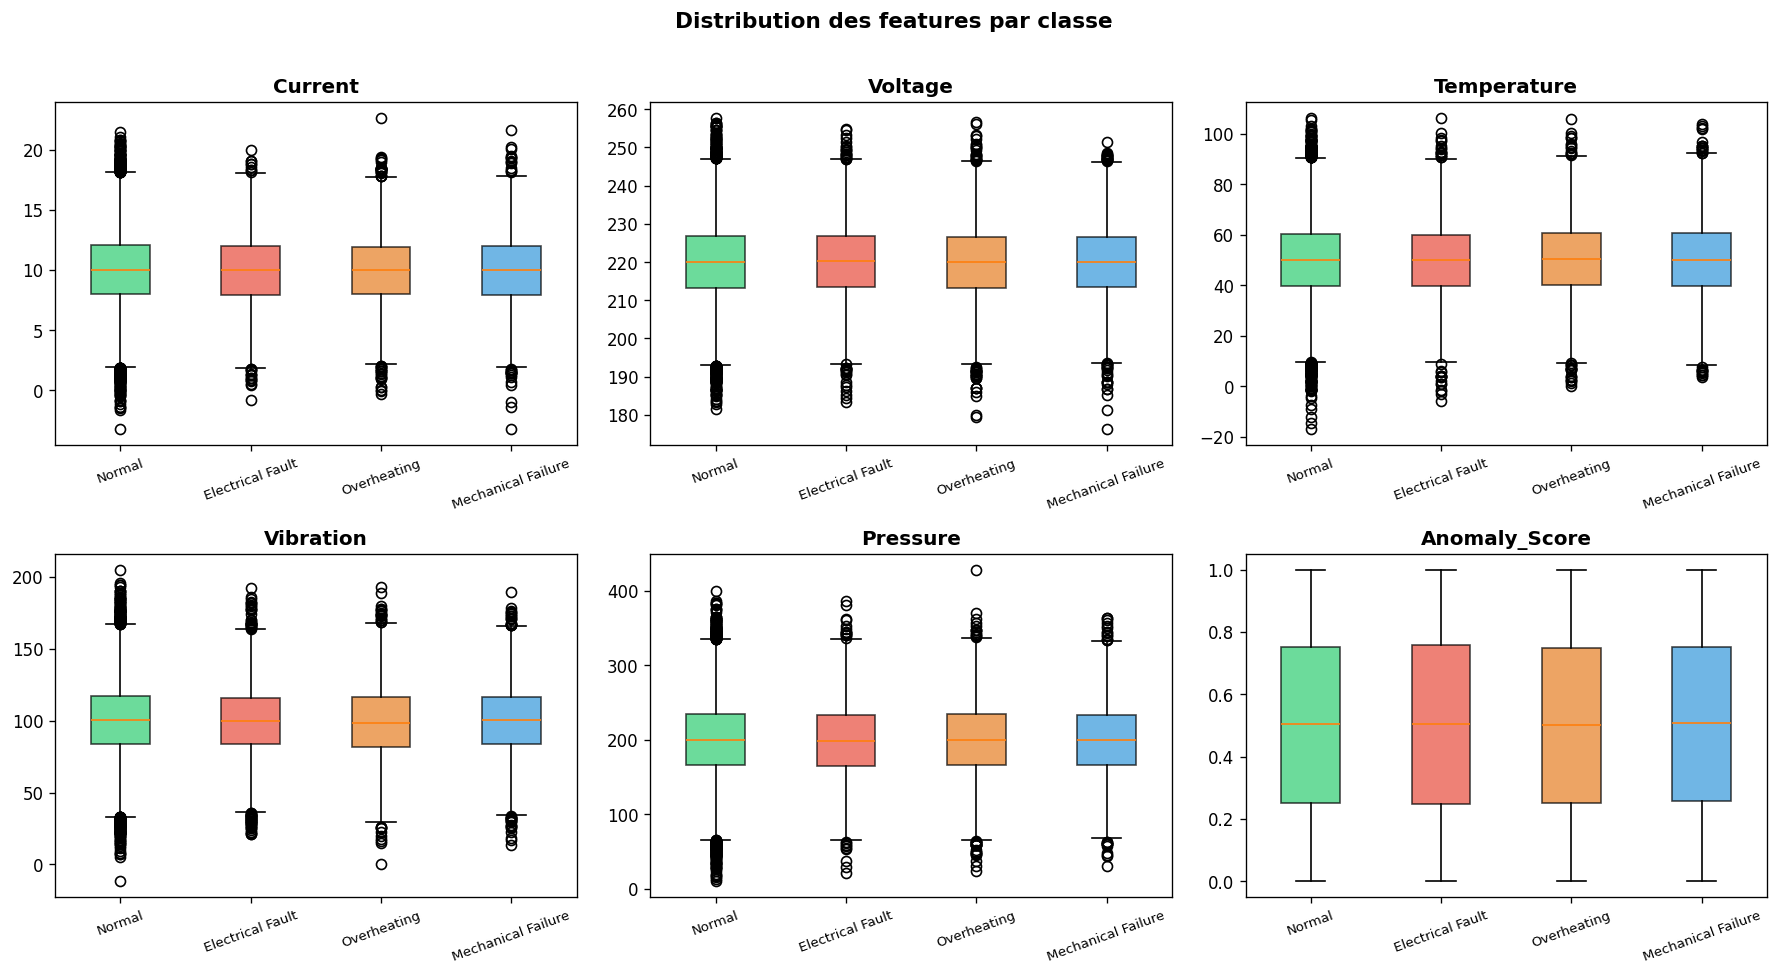

Figure sauvegardee : outputs/boxplots_features.png


In [41]:
# Distribution des features physiques par classe
features_plot = ["Current", "Voltage", "Temperature", "Vibration", "Pressure", "Anomaly_Score"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features_plot):
    data_by_class = [df[df["Label"] == cls][feat].values for cls in label_counts.index]
    bp = ax.boxplot(data_by_class, patch_artist=True, labels=label_counts.index)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, fontweight="bold")
    ax.tick_params(axis="x", rotation=20, labelsize=8)

plt.suptitle("Distribution des features par classe", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "boxplots_features.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/boxplots_features.png")

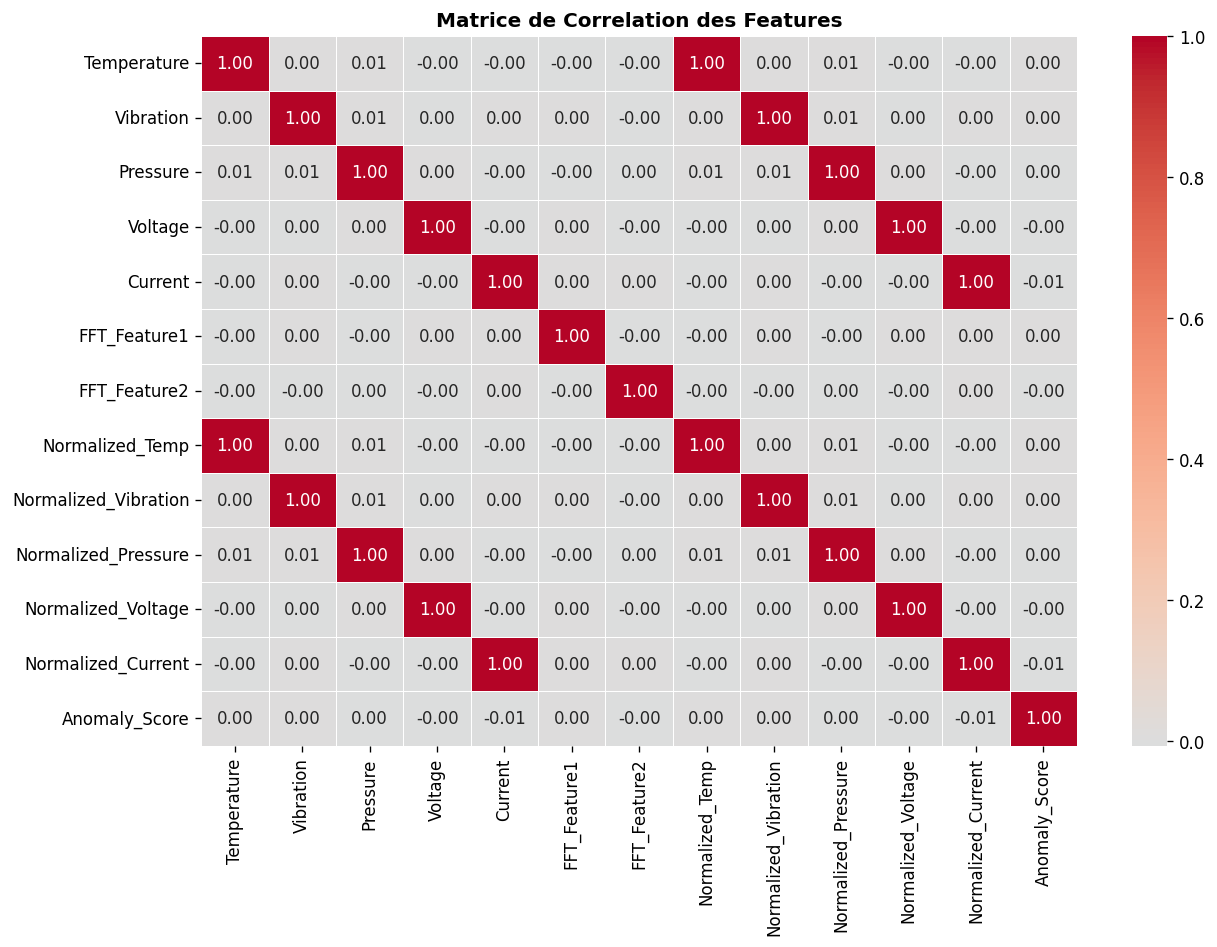

Figure sauvegardee : outputs/correlation_matrix.png


In [42]:
# Matrice de correlation
FEATURE_COLS = [
    "Temperature", "Vibration", "Pressure", "Voltage", "Current",
    "FFT_Feature1", "FFT_Feature2",
    "Normalized_Temp", "Normalized_Vibration", "Normalized_Pressure",
    "Normalized_Voltage", "Normalized_Current", "Anomaly_Score"
]

corr = df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Matrice de Correlation des Features", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "correlation_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/correlation_matrix.png")

---
## 7. Preparation des Donnees (Preprocessing)

Colonnes utilisees comme features (13 colonnes numeriques) :

```
Temperature, Vibration, Pressure, Voltage, Current,
FFT_Feature1, FFT_Feature2,
Normalized_Temp, Normalized_Vibration, Normalized_Pressure,
Normalized_Voltage, Normalized_Current, Anomaly_Score
```

Colonnes exclues : `Timestamp`, `Sensor_ID`, `Fault_Type`, `Fault_Status` (meta-donnees / leakage)

In [43]:
# Features et label
X = df[FEATURE_COLS].values.astype(float)
y_raw = df["Label"].values

# Securite : remplacer NaN/Inf eventuels
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Encodage du label
le    = LabelEncoder()
y_enc = le.fit_transform(y_raw)

# Noms des classes garantis en string
CLASS_NAMES = [str(c) for c in le.classes_]

print("Classes encodees :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i}  ->  {cls}  ({np.sum(y_enc == i):,} echantillons)")

# Split 80% Train / 20% Test (stratifie)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)
print(f"\nTrain : {X_train.shape[0]:,} echantillons")
print(f"Test  : {X_test.shape[0]:,} echantillons")

# Normalisation StandardScaler
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("\nNormalisation appliquee (moyenne=0, ecart-type=1).")

Classes encodees :
  0  ->  Electrical Fault  (5,034 echantillons)
  1  ->  Mechanical Failure  (4,950 echantillons)
  2  ->  Normal  (34,988 echantillons)
  3  ->  Overheating  (5,028 echantillons)

Train : 40,000 echantillons
Test  : 10,000 echantillons

Normalisation appliquee (moyenne=0, ecart-type=1).


---
## 8. Modele 1 — Random Forest Classifier

> Robuste, rapide, interpretable — reference pour le diagnostic industriel.

In [44]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced",   # compense le desequilibre Normal vs Faults
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest — Accuracy : {acc_rf * 100:.2f}%")
print()
print(classification_report(
    y_test, y_pred_rf,
    target_names=CLASS_NAMES,
    zero_division=0
))

Random Forest — Accuracy : 65.13%

                    precision    recall  f1-score   support

  Electrical Fault       0.09      0.03      0.05      1007
Mechanical Failure       0.09      0.02      0.03       990
            Normal       0.70      0.92      0.79      6997
       Overheating       0.08      0.02      0.03      1006

          accuracy                           0.65     10000
         macro avg       0.24      0.25      0.22     10000
      weighted avg       0.51      0.65      0.57     10000



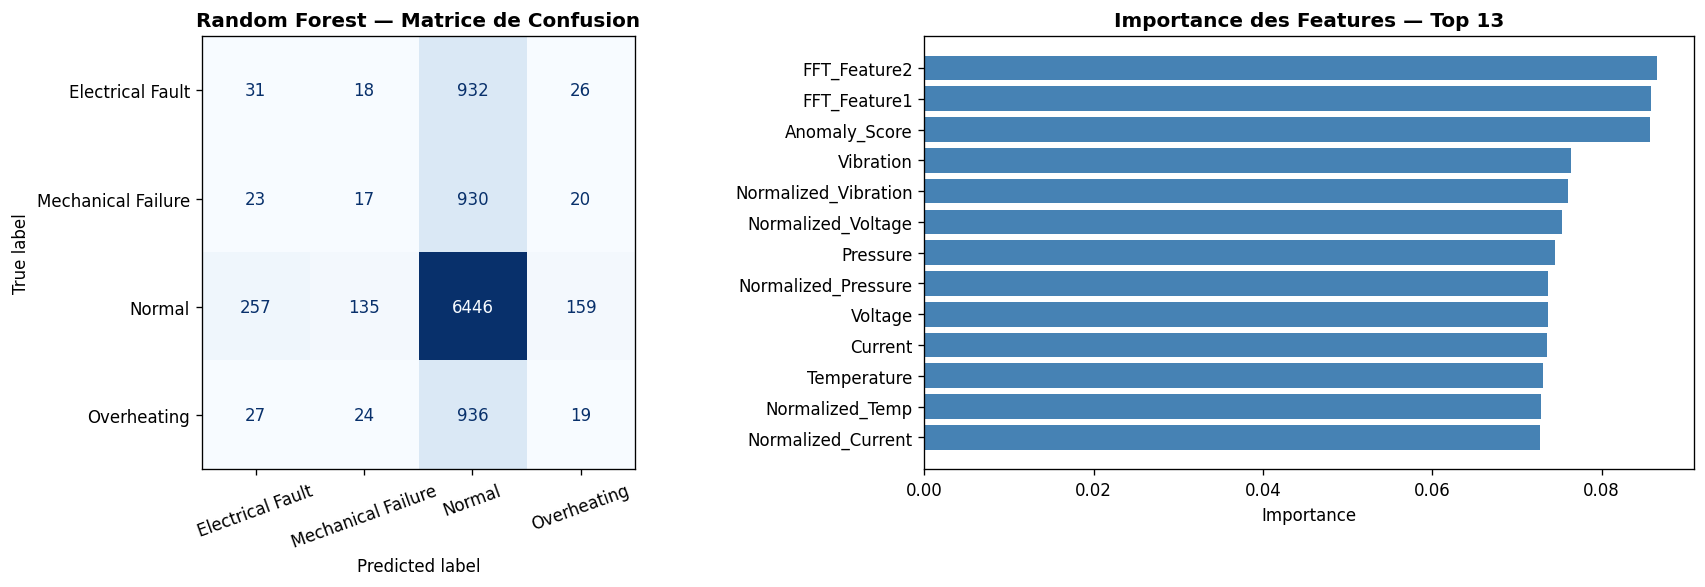

Figure sauvegardee : outputs/rf_results.png


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp  = ConfusionMatrixDisplay(cm_rf, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Random Forest — Matrice de Confusion", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

# Importance des features
importances = rf.feature_importances_
top_n       = min(13, len(FEATURE_COLS))
sorted_idx  = np.argsort(importances)[::-1][:top_n]
axes[1].barh(
    [FEATURE_COLS[i] for i in sorted_idx[::-1]],
    importances[sorted_idx[::-1]],
    color="steelblue"
)
axes[1].set_title(f"Importance des Features — Top {top_n}", fontweight="bold")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rf_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/rf_results.png")

---
## 9. Modele 2 — MLP (Reseau de Neurones sklearn)

Architecture : `Input (13)` -> **128** -> **64** -> **32** -> `Output (4 classes)`

In [46]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    learning_rate_init=0.001,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False
)
mlp.fit(X_train_s, y_train)
y_pred_mlp = mlp.predict(X_test_s)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP — Accuracy   : {acc_mlp * 100:.2f}%")
print(f"MLP — Iterations : {mlp.n_iter_}")
print()
print(classification_report(
    y_test, y_pred_mlp,
    target_names=CLASS_NAMES,
    zero_division=0
))

MLP — Accuracy   : 69.97%
MLP — Iterations : 22

                    precision    recall  f1-score   support

  Electrical Fault       0.00      0.00      0.00      1007
Mechanical Failure       0.00      0.00      0.00       990
            Normal       0.70      1.00      0.82      6997
       Overheating       0.00      0.00      0.00      1006

          accuracy                           0.70     10000
         macro avg       0.17      0.25      0.21     10000
      weighted avg       0.49      0.70      0.58     10000



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matrice de confusion
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap="Oranges", colorbar=False
)
axes[0].set_title("MLP — Matrice de Confusion", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

# Courbe de loss
if hasattr(mlp, "loss_curve_") and mlp.loss_curve_:
    axes[1].plot(mlp.loss_curve_, color="darkorange", linewidth=2, label="Train loss")
    if hasattr(mlp, "validation_scores_") and mlp.validation_scores_:
        ax2 = axes[1].twinx()
        ax2.plot(mlp.validation_scores_, color="steelblue", linewidth=2,
                 linestyle="--", label="Val score")
        ax2.set_ylabel("Validation score", color="steelblue")
    axes[1].set_title("MLP — Courbe de Loss", fontweight="bold")
    axes[1].set_xlabel("Iterations")
    axes[1].set_ylabel("Loss")
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "loss_curve_ non disponible",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("MLP — Courbe de Loss", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mlp_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/mlp_results.png")

---
## 10. Comparaison des Modeles

       COMPARAISON DES PERFORMANCES
               Accuracy  Precision  Recall  F1-Score
Modele                                              
Random Forest     65.13      51.44   65.13     56.60
MLP (sklearn)     69.97      48.96   69.97     57.61


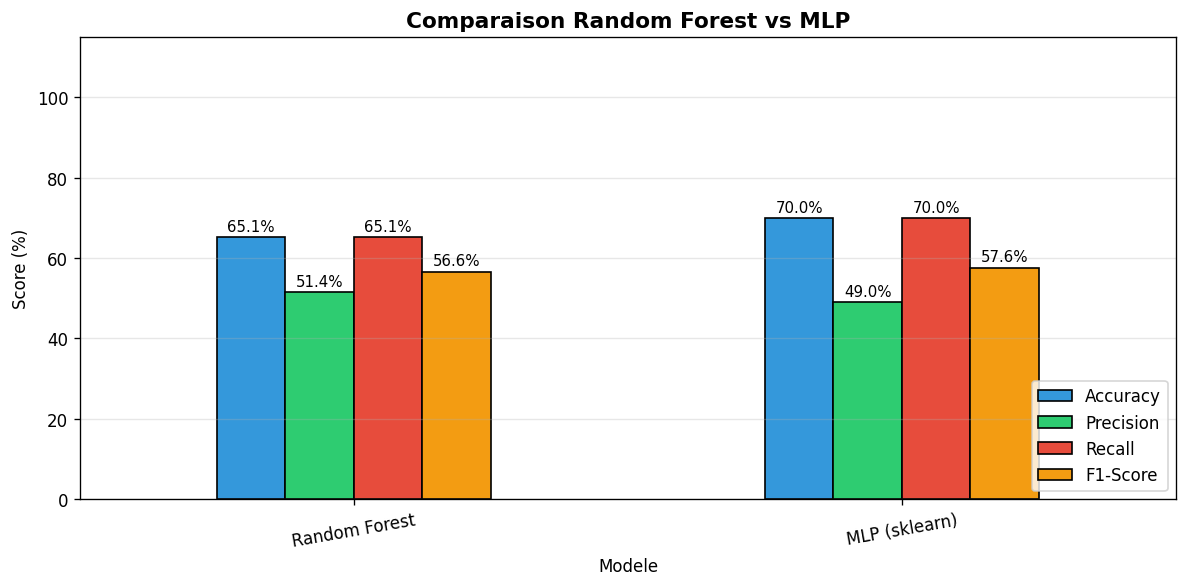

Figure sauvegardee : outputs/comparison.png


In [47]:
def get_metrics(y_true, y_pred, model_name):
    return {
        "Modele"    : model_name,
        "Accuracy"  : round(accuracy_score(y_true, y_pred) * 100, 2),
        "Precision" : round(precision_score(y_true, y_pred, average="weighted", zero_division=0) * 100, 2),
        "Recall"    : round(recall_score(y_true, y_pred, average="weighted", zero_division=0) * 100, 2),
        "F1-Score"  : round(f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100, 2),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_rf,  "Random Forest"),
    get_metrics(y_test, y_pred_mlp, "MLP (sklearn)"),
]).set_index("Modele")

print("=" * 58)
print("       COMPARAISON DES PERFORMANCES")
print("=" * 58)
print(results.to_string())
print("=" * 58)

# Graphique
ax = results.plot(
    kind="bar", figsize=(10, 5),
    color=["#3498db", "#2ecc71", "#e74c3c", "#f39c12"],
    edgecolor="black", ylim=(0, 115)
)
ax.set_title("Comparaison Random Forest vs MLP", fontsize=13, fontweight="bold")
ax.set_ylabel("Score (%)")
ax.set_xticklabels(results.index, rotation=10)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/comparison.png")

In [48]:
# Rapport par classe — detail Normal vs Pannes
print("Rapport detaille par classe — Random Forest :")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, zero_division=0))

print("Rapport detaille par classe — MLP :")
print(classification_report(y_test, y_pred_mlp, target_names=CLASS_NAMES, zero_division=0))

Rapport detaille par classe — Random Forest :
                    precision    recall  f1-score   support

  Electrical Fault       0.09      0.03      0.05      1007
Mechanical Failure       0.09      0.02      0.03       990
            Normal       0.70      0.92      0.79      6997
       Overheating       0.08      0.02      0.03      1006

          accuracy                           0.65     10000
         macro avg       0.24      0.25      0.22     10000
      weighted avg       0.51      0.65      0.57     10000

Rapport detaille par classe — MLP :
                    precision    recall  f1-score   support

  Electrical Fault       0.00      0.00      0.00      1007
Mechanical Failure       0.00      0.00      0.00       990
            Normal       0.70      1.00      0.82      6997
       Overheating       0.00      0.00      0.00      1006

          accuracy                           0.70     10000
         macro avg       0.17      0.25      0.21     10000
      weighte

---
## 11. Sauvegarde des Modeles

In [49]:
joblib.dump(rf,           os.path.join(OUTPUT_DIR, "rf_model.joblib"))
joblib.dump(mlp,          os.path.join(OUTPUT_DIR, "mlp_model.joblib"))
joblib.dump(scaler,       os.path.join(OUTPUT_DIR, "scaler.joblib"))
joblib.dump(le,           os.path.join(OUTPUT_DIR, "label_encoder.joblib"))
joblib.dump(FEATURE_COLS, os.path.join(OUTPUT_DIR, "feature_cols.joblib"))

print(f"Modeles sauvegardes dans '{OUTPUT_DIR}/' :")
for fname in os.listdir(OUTPUT_DIR):
    if fname.endswith(".joblib"):
        size = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
        print(f"  {fname:<30} ({size/1024:.1f} KB)")

Modeles sauvegardes dans 'outputs/' :
  feature_cols.joblib            (0.2 KB)
  label_encoder.joblib           (0.5 KB)
  mlp_model.joblib               (295.9 KB)
  rf_model.joblib                (53498.2 KB)
  scaler.joblib                  (0.9 KB)


---
## 12. Prediction en Temps Reel

> Entrez les valeurs des capteurs pour simuler une prediction sur un nouvel echantillon.

In [50]:
def predict_fault(
    temperature=50.0,  vibration=80.0,   pressure=200.0,
    voltage=230.0,     current=10.0,     fft1=0.5,
    fft2=0.5,
    norm_temp=None,    norm_vib=None,    norm_pres=None,
    norm_volt=None,    norm_curr=None,   anomaly_score=0.3,
    model=None
):
    """
    Predit le type de panne a partir des valeurs capteurs.

    Parametres principaux
    ---------------------
    temperature    : float  -- Temperature (C)
    vibration      : float  -- Vibration
    pressure       : float  -- Pression
    voltage        : float  -- Tension (V)
    current        : float  -- Courant (A)
    fft1, fft2     : float  -- Caracteristiques FFT [0-1]
    anomaly_score  : float  -- Score d anomalie [0-1]
    model          : modele sklearn (rf par defaut)
    """
    if model is None:
        model = rf

    # Valeurs normalisees par defaut : min-max simples
    train_df = pd.DataFrame(X_train, columns=FEATURE_COLS)
    def auto_norm(val, col):
        mn, mx = train_df[col].min(), train_df[col].max()
        return (val - mn) / (mx - mn) if mx > mn else 0.5

    if norm_temp  is None: norm_temp  = auto_norm(temperature, "Temperature")
    if norm_vib   is None: norm_vib   = auto_norm(vibration,   "Vibration")
    if norm_pres  is None: norm_pres  = auto_norm(pressure,    "Pressure")
    if norm_volt  is None: norm_volt  = auto_norm(voltage,     "Voltage")
    if norm_curr  is None: norm_curr  = auto_norm(current,     "Current")

    sample = np.array([[
        temperature, vibration, pressure, voltage, current,
        fft1, fft2,
        norm_temp, norm_vib, norm_pres, norm_volt, norm_curr,
        anomaly_score
    ]], dtype=float)

    sample   = np.nan_to_num(sample, nan=0.0)
    sample_s = scaler.transform(sample)

    pred_idx   = model.predict(sample_s)[0]
    pred_proba = model.predict_proba(sample_s)[0]
    pred_label = le.inverse_transform([pred_idx])[0]

    print(f"  --> Prediction   : {pred_label}")
    print(f"      Confiance    : {np.max(pred_proba)*100:.1f}%")
    for cls, prob in zip(CLASS_NAMES, pred_proba):
        bar = "#" * int(prob * 30)
        print(f"      P({cls:<20}) = {prob*100:5.1f}%  {bar}")
    return pred_label

print("Fonction predict_fault() prete.")

Fonction predict_fault() prete.


In [51]:
print("=" * 60)
print("TEST 1 — Fonctionnement Normal")
print("-" * 60)
predict_fault(temperature=50, vibration=80, pressure=200,
              voltage=230, current=10, anomaly_score=0.2)

print()
print("TEST 2 — Surchauffe (Overheating)")
print("-" * 60)
predict_fault(temperature=95, vibration=130, pressure=290,
              voltage=220, current=18, anomaly_score=0.85)

print()
print("TEST 3 — Panne Electrique (Electrical Fault)")
print("-" * 60)
predict_fault(temperature=55, vibration=75, pressure=195,
              voltage=180, current=22, anomaly_score=0.78)

print()
print("TEST 4 — Defaillance Mecanique (Mechanical Failure)")
print("-" * 60)
predict_fault(temperature=60, vibration=195, pressure=310,
              voltage=225, current=14, anomaly_score=0.91)
print("=" * 60)

TEST 1 — Fonctionnement Normal
------------------------------------------------------------
  --> Prediction   : Normal
      Confiance    : 27.1%
      P(Electrical Fault    ) =  24.8%  #######
      P(Mechanical Failure  ) =  23.0%  ######
      P(Normal              ) =  27.1%  ########
      P(Overheating         ) =  25.1%  #######

TEST 2 — Surchauffe (Overheating)
------------------------------------------------------------
  --> Prediction   : Normal
      Confiance    : 35.5%
      P(Electrical Fault    ) =  27.7%  ########
      P(Mechanical Failure  ) =  19.7%  #####
      P(Normal              ) =  35.5%  ##########
      P(Overheating         ) =  17.0%  #####

TEST 3 — Panne Electrique (Electrical Fault)
------------------------------------------------------------
  --> Prediction   : Normal
      Confiance    : 40.9%
      P(Electrical Fault    ) =  14.3%  ####
      P(Mechanical Failure  ) =  19.3%  #####
      P(Normal              ) =  40.9%  ############
      P(Over

---
## Recapitulatif du Pipeline

```
CSV brut (50 000 lignes)
    |
    v
Construction du label propre
    Fault_Status == 0  ->  "Normal"
    Fault_Status == 1  ->  Fault_Type (Electrical Fault / Overheating / Mechanical Failure)
    |
    v
Selection de 13 features numeriques (capteurs + FFT + scores normalises)
    |
    v
Split stratifie 80% Train / 20% Test
    |
    v
StandardScaler (normalisation)
    |
    +---> Random Forest  (200 arbres, max_depth=15, balanced)
    |
    +---> MLP sklearn    (128->64->32, ReLU, Adam, early_stopping)
              |
              v
         Evaluation (Accuracy, F1, Precision, Recall, Confusion Matrix)
              |
              v
         Sauvegarde .joblib dans outputs/
```

---
*Projet de Fin d'Annee II — Diagnostic de Moteurs DC 12V par IA*